In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
dataset_path = "/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])

# Convert symptom columns to description
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

# Load tokenizers
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
ernie_tokenizer = AutoTokenizer.from_pretrained("nghuyong/ernie-2.0-base-en")

# Dataset class
class SymptomHybridDataset(Dataset):
    def __init__(self, texts, labels, xlmr_tokenizer, ernie_tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.xlmr_tokenizer = xlmr_tokenizer
        self.ernie_tokenizer = ernie_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        xlmr_encoding = self.xlmr_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        ernie_encoding = self.ernie_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {
            "xlmr": {k: v.squeeze(0) for k, v in xlmr_encoding.items()},
            "ernie": {k: v.squeeze(0) for k, v in ernie_encoding.items()},
            "label": torch.tensor(self.labels[idx])
        }

# Data loaders
train_dataset = SymptomHybridDataset(X_train, y_train, xlmr_tokenizer, ernie_tokenizer)
test_dataset = SymptomHybridDataset(X_test, y_test, xlmr_tokenizer, ernie_tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Hybrid model
class XLMR_ERNIE_Classifier(nn.Module):
    def __init__(self, num_labels):
        super(XLMR_ERNIE_Classifier, self).__init__()
        self.xlmr = AutoModel.from_pretrained("xlm-roberta-base")
        self.ernie = AutoModel.from_pretrained("nghuyong/ernie-2.0-base-en")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768 * 2, num_labels)

    def forward(self, xlmr_inputs, ernie_inputs):
        xlmr_output = self.xlmr(**xlmr_inputs).last_hidden_state[:, 0, :]
        ernie_output = self.ernie(**ernie_inputs).last_hidden_state[:, 0, :]
        combined = torch.cat((xlmr_output, ernie_output), dim=1)
        out = self.dropout(combined)
        return self.classifier(out)

# Initialize model
model = XLMR_ERNIE_Classifier(num_labels=len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# Training loop
num_epochs = 3
train_loss_values, test_loss_values = [], []
train_accuracies, test_accuracies = [], []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train, total_train = 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        xlmr_inputs = {k: v.to(device) for k, v in batch["xlmr"].items()}
        ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
        labels = batch["label"].to(device)

        outputs = model(xlmr_inputs, ernie_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    model.eval()
    total_test_loss = 0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for batch in test_loader:
            xlmr_inputs = {k: v.to(device) for k, v in batch["xlmr"].items()}
            ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
            labels = batch["label"].to(device)

            outputs = model(xlmr_inputs, ernie_inputs)
            loss = criterion(outputs, labels)

            total_test_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    train_loss_values.append(avg_train_loss)
    test_loss_values.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {test_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch 1: Train Loss = 1.2359, Train Acc = 0.7313, Test Loss = 0.5041, Test Acc = 0.8363
Epoch 2: Train Loss = 0.4936, Train Acc = 0.8411, Test Loss = 0.4484, Test Acc = 0.8465
Epoch 3: Train Loss = 0.4328, Train Acc = 0.8502, Test Loss = 0.4249, Test Acc = 0.8469

Total Training Time: 32257.08 seconds


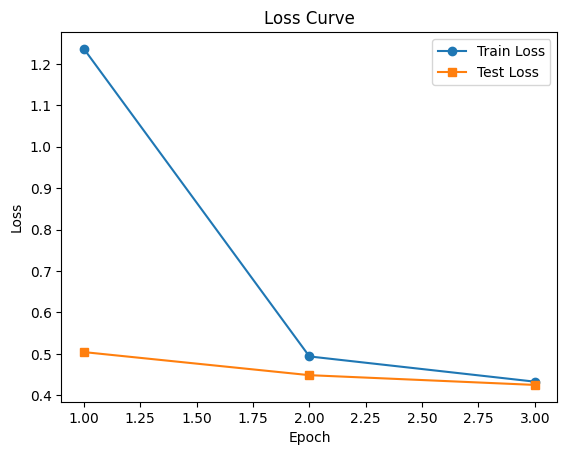

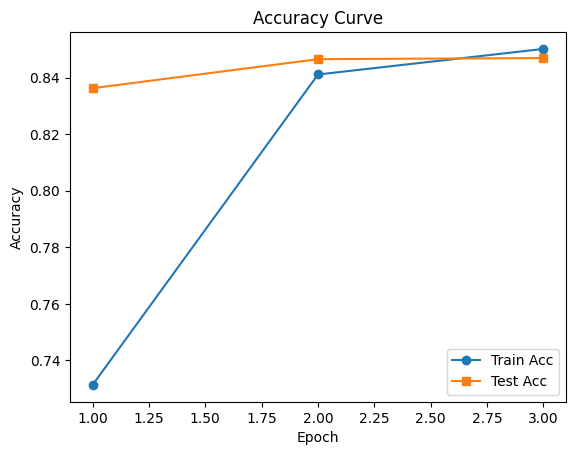


Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.91      1.00      0.95        20
                                        abdominal hernia       0.94      0.89      0.91        81
                                         abscess of nose       0.85      0.86      0.85        58
                                     abscess of the lung       1.00      0.83      0.91         6
                                  abscess of the pharynx       0.93      0.87      0.90        63
                                    acanthosis nigricans       0.75      0.50      0.60         6
                                               acariasis       1.00      0.80      0.89         5
                                               achalasia       0.73      0.80      0.76        20
                                                    acne       0.93      0.72      0.81      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [2]:

# Plotting
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), test_loss_values, marker='s', label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Acc')
plt.plot(range(1, num_epochs+1), test_accuracies, marker='s', label='Test Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Final evaluation
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        xlmr_inputs = {k: v.to(device) for k, v in batch["xlmr"].items()}
        ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
        labels = batch["label"].to(device)

        outputs = model(xlmr_inputs, ernie_inputs)
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_))


In [5]:

torch.save(model, "/kaggle/working/xlm-roberta+ernie.pth")


In [6]:
torch.save(model, "/kaggle/working/xlm-roberta+ernie.h5")